<a href="https://colab.research.google.com/github/sathursiyakrishnamoorthy/Data-Science-Project-Hotel-A/blob/main/EDA_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pandas matplotlib seaborn

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

In [5]:
df = pd.read_csv("/content/drive/MyDrive/DATA SCIENE PROJECT LIFECYCLE/Hotel-A-train.csv")

df.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,7/1/2015,7/2/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,Yes,10,218
1,77491756,F,49,Latino,Mid-School,50K -- 100K,East,City Hotel,7/1/2015,7/2/2015,...,BB,No,No,Refundable,Online,Yes,Check-Out,No,0,185
2,73747291,F,42,caucasian,Grad,<25K,East,City Hotel,7/2/2015,7/6/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,119
3,67301739,M,25,African American,College,>100K,South,Airport Hotels,7/2/2015,7/3/2015,...,BB,No,No,Refundable,Agent,Yes,Check-Out,Yes,5,144
4,77222321,F,62,Latino,High-School,25K --50K,East,Resort,7/3/2015,7/4/2015,...,BB,No,No,No Deposit,Direct,No,Check-Out,Yes,10,242


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27499 entries, 0 to 27498
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Reservation-id          27499 non-null  int64 
 1   Gender                  27499 non-null  object
 2   Age                     27499 non-null  int64 
 3   Ethnicity               27499 non-null  object
 4   Educational_Level       27499 non-null  object
 5   Income                  27499 non-null  object
 6   Country_region          27499 non-null  object
 7   Hotel_Type              27499 non-null  object
 8   Expected_checkin        27499 non-null  object
 9   Expected_checkout       27499 non-null  object
 10  Booking_date            27499 non-null  object
 11  Adults                  27499 non-null  int64 
 12  Children                27499 non-null  int64 
 13  Babies                  27499 non-null  int64 
 14  Meal_Type               27499 non-null  object
 15  Vi

,Reservation-id,Age,Adults,Children,Babies,Discount_Rate,Room_Rate
count,2.749900e+04,27499.000000,27499.000000,27499.000000,27499.000000,27499.000000,27499.000000
mean,5.016461e+07,43.977454,2.333576,1.743882,0.351540,12.495182,175.136478
std,2.886911e+07,15.303148,1.176526,0.721972,0.573326,11.206036,43.877087
min,3.154000e+03,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000
25%,2.523943e+07,31.000000,2.000000,1.000000,0.000000,5.000000,137.000000
50%,5.014996e+07,44.000000,2.000000,2.000000,0.000000,10.000000,175.000000
75%,7.518288e+07,57.000000,3.000000,2.000000,1.000000,20.000000,214.000000
max,9.999900e+07,70.000000,5.000000,3.000000,2.000000,40.000000,250.000000


/tmp/ipykernel_6754/1294773552.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'Check-out {status_counts[0]/sum(status_counts)*100:.1f}%',
/tmp/ipykernel_6754/1294773552.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'Cancelled {status_counts[1]/sum(status_counts)*100:.1f}%',
/tmp/ipykernel_6754/1294773552.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  f'No-show {status_counts[2]/sum(status_counts)*100:.1f}%'


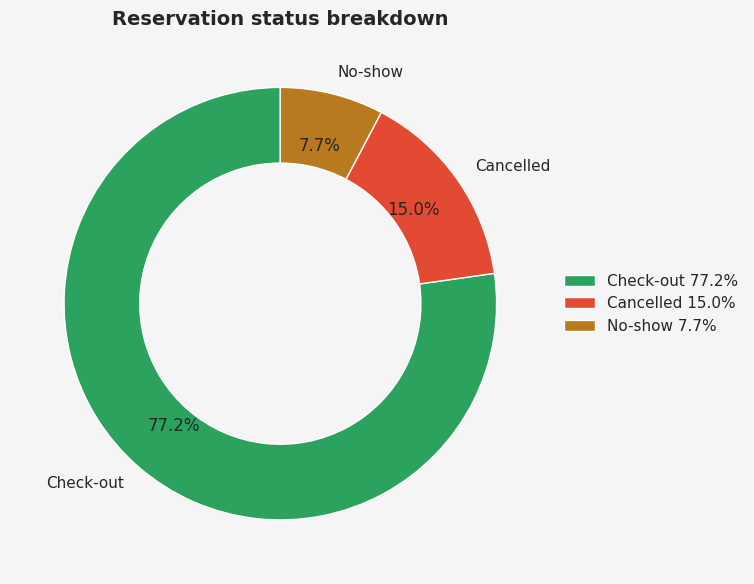

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

#Clean text
df['Reservation_Status'] = df['Reservation_Status'].str.strip().str.lower()

#Fixing Check-out variations
df['Reservation_Status'] = df['Reservation_Status'].replace({
    'check_out': 'check-out',
    'check out': 'check-out',
    'checkout': 'check-out'
})

#Standardizing other names
df['Reservation_Status'] = df['Reservation_Status'].replace({
    'cancelled': 'canceled',
    'no show': 'no-show'
})

#Counting values
status_counts = df['Reservation_Status'].value_counts()

# Ensuring correct order and avoid missing values
status_counts = status_counts.reindex(['check-out', 'canceled', 'no-show'], fill_value=0)

#Colors
colors = ['#2ca25f', '#e34a33', '#b8791f']

#Creating figure
plt.figure(figsize=(8,6), facecolor='#f5f5f5')

# Donut chart
wedges, texts, autotexts = plt.pie(
    status_counts,
    labels=['Check-out', 'Cancelled', 'No-show'],
    colors=colors,
    startangle=90,
    autopct='%1.1f%%',
    pctdistance=0.75,
    wedgeprops={'width':0.35, 'edgecolor':'white'}
)

# Title
plt.title("Reservation status breakdown", fontsize=14, fontweight='bold')

#creating Legend on RIGHT side
labels = [
    f'Check-out {status_counts[0]/sum(status_counts)*100:.1f}%',
    f'Cancelled {status_counts[1]/sum(status_counts)*100:.1f}%',
    f'No-show {status_counts[2]/sum(status_counts)*100:.1f}%'
]

plt.legend(
    wedges,
    labels,
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

# Layout fix
plt.tight_layout()

# Show chart
plt.show()

In [8]:
#See real values
print("Before cleaning:")
print(df['Hotel_Type'].unique())

#Clean properly
df['Hotel_Type'] = df['Hotel_Type'].astype(str).str.strip().str.lower()

df['Hotel_Type'] = df['Hotel_Type'].replace({
    'airport hotel': 'airport',
    'airport_hotel': 'airport',
    'airport ': 'airport',
    'city hotel': 'city',
    'city_hotel': 'city',
    'resort hotel': 'resort',
    'resort_hotel': 'resort'
})

df['Hotel_Type'] = df['Hotel_Type'].str.title()

# Checking again
print("\nAfter cleaning:")
print(df['Hotel_Type'].value_counts())

Before cleaning:
['City Hotel' 'Airport Hotels' 'Resort']

After cleaning:
Hotel_Type
Airport Hotels    9258
City              9134
Resort            9107
Name: count, dtype: int64


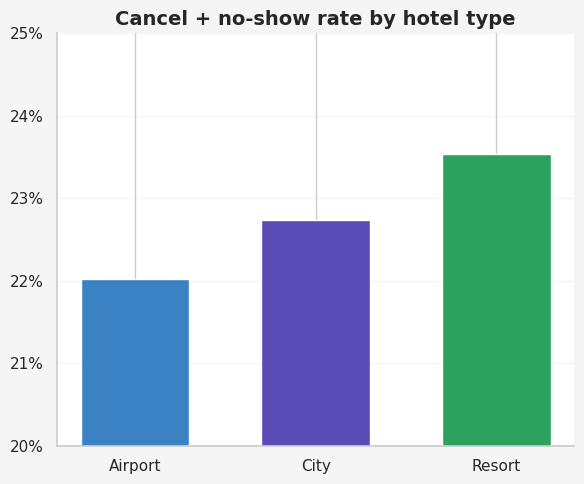

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#CLEAN Reservation_Status
df['Reservation_Status'] = df['Reservation_Status'].astype(str).str.strip().str.lower()

df['Reservation_Status'] = df['Reservation_Status'].replace({
    'check_out': 'check-out',
    'check out': 'check-out',
    'checkout': 'check-out',
    'cancelled': 'canceled',
    'no show': 'no-show'
})

#Cleaning Hotel_Type
df['Hotel_Type'] = df['Hotel_Type'].astype(str).str.strip().str.lower()

#Flexible cleaning
df['Hotel_Type'] = df['Hotel_Type'].apply(lambda x:
    'airport' if 'airport' in x else
    'city' if 'city' in x else
    'resort' if 'resort' in x else x
)

df['Hotel_Type'] = df['Hotel_Type'].str.title()

#Create Cancel + No-show
df['is_failed'] = df['Reservation_Status'].isin(['canceled', 'no-show'])

#Group
hotel_cancel = df.groupby('Hotel_Type')['is_failed'].mean() * 100

#Only show categories that exist
hotel_cancel = hotel_cancel.sort_index()

#Colors mapping
color_map = {
    'Airport': '#3b82c4',
    'City': '#5b4bb7',
    'Resort': '#2ca25f'
}

colors = [color_map.get(x, '#999999') for x in hotel_cancel.index]

#Plot
plt.figure(figsize=(6,5), facecolor='#f5f5f5')

plt.bar(
    hotel_cancel.index,
    hotel_cancel.values,
    color=colors,
    width=0.6
)

plt.title("Cancel + no-show rate by hotel type", fontsize=14, fontweight='bold')

plt.ylim(20, 25)
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x:.0f}%')

sns.despine()
plt.grid(axis='y', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()


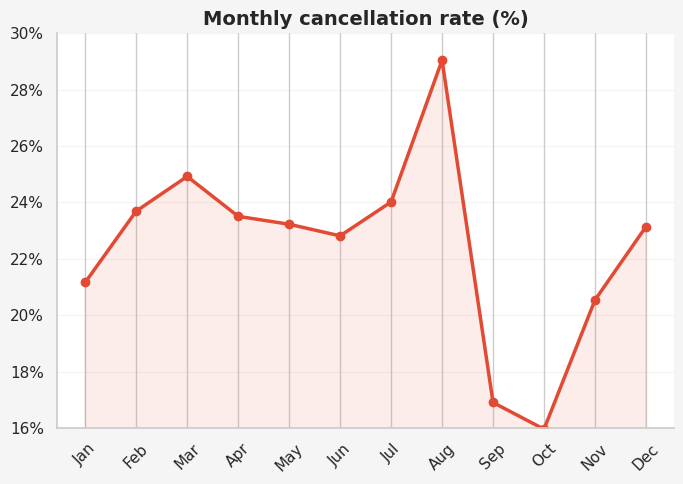

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid")

#Cleaning Reservation_Status
df['Reservation_Status'] = df['Reservation_Status'].astype(str).str.strip().str.lower()

df['Reservation_Status'] = df['Reservation_Status'].replace({
    'check_out': 'check-out',
    'check out': 'check-out',
    'checkout': 'check-out',
    'cancelled': 'canceled',
    'no show': 'no-show'
})

#Convert date
df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])

# Extract month name (short format like Jan, Feb)
df['month'] = df['Expected_checkin'].dt.strftime('%b')

#Create cancel + no-show flag
df['is_failed'] = df['Reservation_Status'].isin(['canceled', 'no-show'])

#Calculate monthly rate
monthly_cancel = df.groupby('month')['is_failed'].mean() * 100

# Ensure correct month order
months_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_cancel = monthly_cancel.reindex(months_order)

#  Plot
plt.figure(figsize=(7,5), facecolor='#f5f5f5')

# Line
plt.plot(
    monthly_cancel.index,
    monthly_cancel.values,
    color='#e34a33',
    marker='o',
    linewidth=2.5
)

# Fill area
plt.fill_between(
    monthly_cancel.index,
    monthly_cancel.values,
    color='#e34a33',
    alpha=0.1
)

# Title
plt.title("Monthly cancellation rate (%)", fontsize=14, fontweight='bold')

# Y-axis formatting
plt.ylim(16, 30)
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x:.0f}%')

# Rotate months
plt.xticks(rotation=45)

# Remove top/right borders
sns.despine()

# Light grid
plt.grid(axis='y', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6754/3341571543.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lead_cancel = df.groupby('lead_group')['is_failed'].mean() * 100


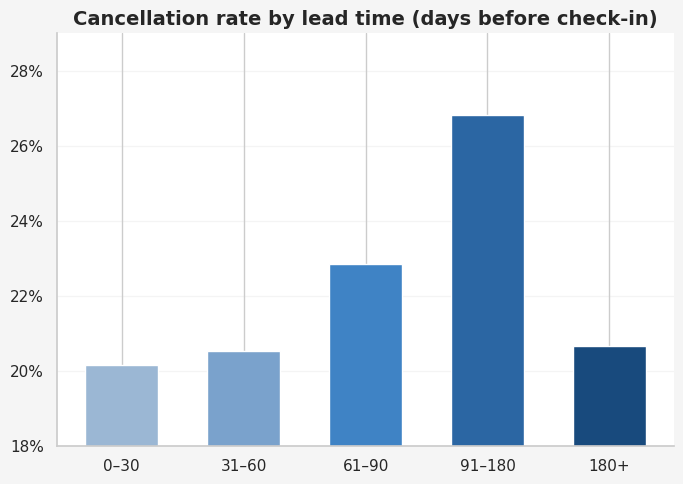

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid")

#Clean Reservation_Status
df['Reservation_Status'] = df['Reservation_Status'].astype(str).str.strip().str.lower()

df['Reservation_Status'] = df['Reservation_Status'].replace({
    'check_out': 'check-out',
    'check out': 'check-out',
    'checkout': 'check-out',
    'cancelled': 'canceled',
    'no show': 'no-show'
})

# Convert dates
df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])
df['Booking_date'] = pd.to_datetime(df['Booking_date'])

#Create lead time
df['lead_time'] = (df['Expected_checkin'] - df['Booking_date']).dt.days

# Create cancel + no-show flag
df['is_failed'] = df['Reservation_Status'].isin(['canceled', 'no-show'])

# Create bins
bins = [0, 30, 60, 90, 180, 3650]  # large upper bound
labels = ['0–30', '31–60', '61–90', '91–180', '180+']

df['lead_group'] = pd.cut(df['lead_time'], bins=bins, labels=labels, right=True)

# Calculate cancellation rate
lead_cancel = df.groupby('lead_group')['is_failed'].mean() * 100

# Ensure order
lead_cancel = lead_cancel.reindex(labels)

#  Colors
colors = ['#9bb7d4', '#7aa2cc', '#3f83c5', '#2b66a3', '#184a7d']

# Plot
plt.figure(figsize=(7,5), facecolor='#f5f5f5')

bars = plt.bar(
    lead_cancel.index,
    lead_cancel.values,
    color=colors,
    width=0.6
)

# Title
plt.title("Cancellation rate by lead time (days before check-in)", fontsize=14, fontweight='bold')

# Y-axis
plt.ylim(18, 29)
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x:.0f}%')

# Clean style
sns.despine()
plt.grid(axis='y', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6754/557027878.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_cancel = df.groupby('income_bracket')['is_failed'].mean() * 100


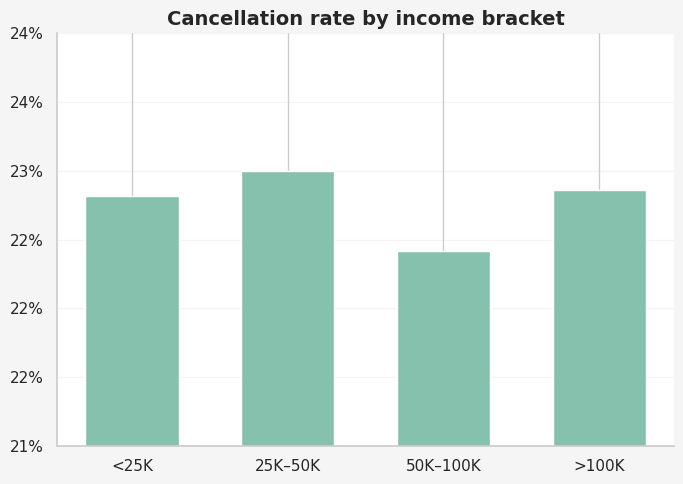

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid")

# Clean Reservation_Status
df['Reservation_Status'] = df['Reservation_Status'].astype(str).str.strip().str.lower()

df['Reservation_Status'] = df['Reservation_Status'].replace({
    'check_out': 'check-out',
    'check out': 'check-out',
    'checkout': 'check-out',
    'cancelled': 'canceled',
    'no show': 'no-show'
})

# Create cancel + no-show flag
df['is_failed'] = df['Reservation_Status'].isin(['canceled', 'no-show'])

# Clean and convert 'Income' to a numerical representation
# Define a mapping dictionary to convert string income ranges to numerical midpoints
income_mapping = {
    '<25K': 12500,        # Midpoint for 0-25K
    '25K --50K': 37500,   # Midpoint for 25K-50K
    '50K -- 100K': 75000, # Midpoint for 50K-100K
    '>100K': 150000,      # Representative value for >100K
    '25K -- 50K': 37500,  # Handle potential space variation
    '50K --100K': 75000,  # Handle potential space variation
    # Add more categories if they exist in your actual data, e.g., 'Not Disclosed'
}

# Apply the mapping to create a new numerical column
df['Income_numeric'] = df['Income'].map(income_mapping)

# Define bins and labels for pd.cut
bins = [0, 25000, 50000, 100000, 1000000] # Ensure upper bound accommodates all >100K values
labels = ['<25K', '25K–50K', '50K–100K', '>100K']

# Now apply pd.cut on the numerical 'Income_numeric' column
df['income_bracket'] = pd.cut(df['Income_numeric'], bins=bins, labels=labels, right=False)

#Calculate cancellation rate
# The groupby will automatically handle any NaNs generated by pd.cut (e.g., if 'Income_numeric' had NaNs)
income_cancel = df.groupby('income_bracket')['is_failed'].mean() * 100

# Ensure correct order for plotting
income_cancel = income_cancel.reindex(labels)

#Color
color = '#86c1ad'

#Plot
plt.figure(figsize=(7,5), facecolor='#f5f5f5')

bars = plt.bar(
    income_cancel.index,
    income_cancel.values,
    color=color,
    width=0.6
)

# Title
plt.title("Cancellation rate by income bracket", fontsize=14, fontweight='bold')

# Y-axis
plt.ylim(21, 24)
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x:.0f}%')

# Clean style
sns.despine()
plt.grid(axis='y', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6754/2554652968.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_cancel = df.groupby('age_group')['is_failed'].mean() * 100


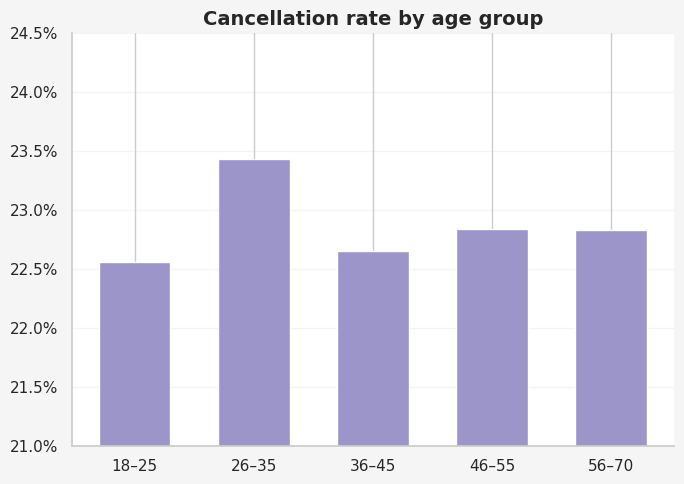

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid")

# Clean Reservation_Status
df['Reservation_Status'] = df['Reservation_Status'].astype(str).str.strip().str.lower()

df['Reservation_Status'] = df['Reservation_Status'].replace({
    'check_out': 'check-out',
    'check out': 'check-out',
    'checkout': 'check-out',
    'cancelled': 'canceled',
    'no show': 'no-show'
})

#Create cancel + no-show flag
df['is_failed'] = df['Reservation_Status'].isin(['canceled', 'no-show'])

#Create age groups
bins = [18, 25, 35, 45, 55, 70]
labels = ['18–25', '26–35', '36–45', '46–55', '56–70']

df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

#Calculate cancellation rate
age_cancel = df.groupby('age_group')['is_failed'].mean() * 100

# Ensure correct order
age_cancel = age_cancel.reindex(labels)

# 🎨 Color (soft purple like image)
color = '#9b95c9'

#Plot
plt.figure(figsize=(7,5), facecolor='#f5f5f5')

bars = plt.bar(
    age_cancel.index,
    age_cancel.values,
    color=color,
    width=0.6
)

# Title
plt.title("Cancellation rate by age group", fontsize=14, fontweight='bold')

# Y-axis formatting
plt.ylim(21, 24.5)
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x:.1f}%')

# Clean style
sns.despine()
plt.grid(axis='y', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()

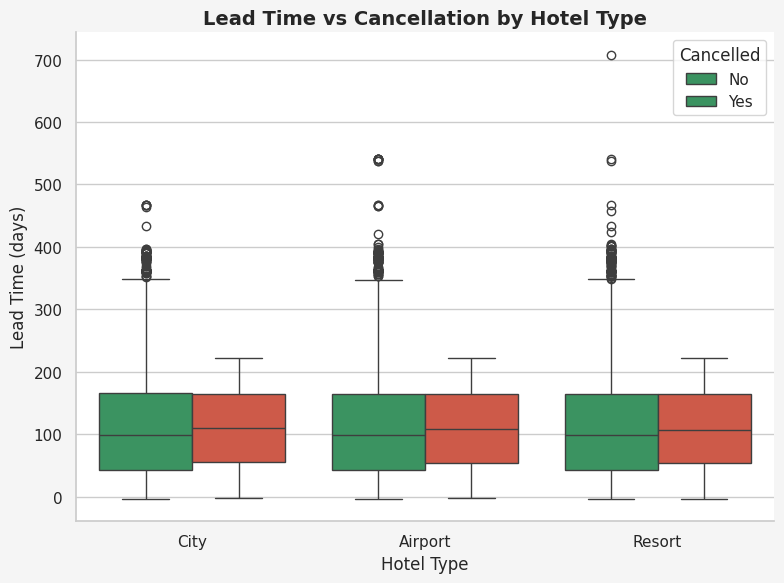

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#Clean Reservation_Status
df['Reservation_Status'] = df['Reservation_Status'].astype(str).str.strip().str.lower()

df['Reservation_Status'] = df['Reservation_Status'].replace({
    'check_out': 'check-out',
    'check out': 'check-out',
    'checkout': 'check-out',
    'cancelled': 'canceled',
    'no show': 'no-show'
})

# Clean Hotel_Type
df['Hotel_Type'] = df['Hotel_Type'].astype(str).str.strip().str.lower()
df['Hotel_Type'] = df['Hotel_Type'].apply(lambda x:
    'airport' if 'airport' in x else
    'city' if 'city' in x else
    'resort' if 'resort' in x else x
)
df['Hotel_Type'] = df['Hotel_Type'].str.title()

# Create lead time
df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])
df['Booking_date'] = pd.to_datetime(df['Booking_date'])
df['lead_time'] = (df['Expected_checkin'] - df['Booking_date']).dt.days

#Create cancel flag
df['is_failed'] = df['Reservation_Status'].isin(['canceled', 'no-show'])

#Plot
plt.figure(figsize=(8,6), facecolor='#f5f5f5')

sns.boxplot(
    x='Hotel_Type',
    y='lead_time',
    hue='is_failed',
    data=df,
    palette=['#2ca25f', '#e34a33']
)

plt.title("Lead Time vs Cancellation by Hotel Type", fontsize=14, fontweight='bold')

plt.ylabel("Lead Time (days)")
plt.xlabel("Hotel Type")

plt.legend(title="Cancelled", labels=["No", "Yes"])

sns.despine()
plt.tight_layout()
plt.show()

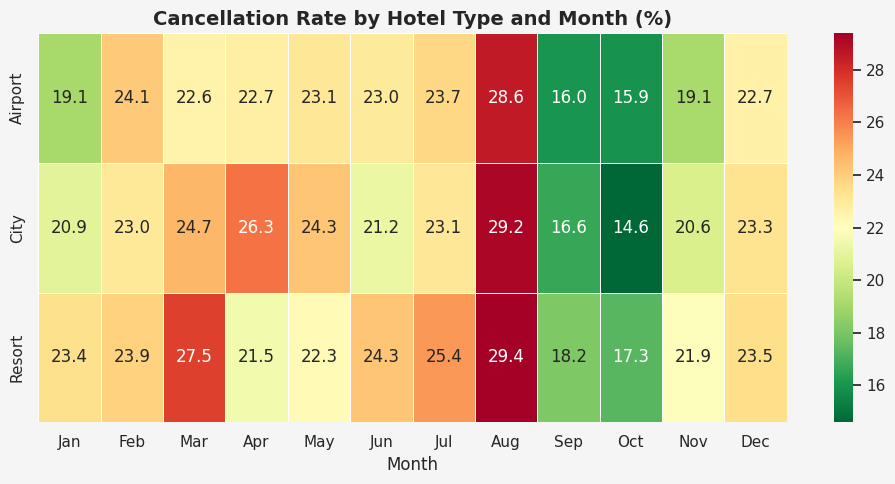

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Clean Reservation_Status
df['Reservation_Status'] = df['Reservation_Status'].astype(str).str.strip().str.lower()

df['Reservation_Status'] = df['Reservation_Status'].replace({
    'check_out': 'check-out',
    'check out': 'check-out',
    'checkout': 'check-out',
    'cancelled': 'canceled',
    'no show': 'no-show'
})

# Clean Hotel_Type
df['Hotel_Type'] = df['Hotel_Type'].astype(str).str.strip().str.lower()
df['Hotel_Type'] = df['Hotel_Type'].apply(lambda x:
    'airport' if 'airport' in x else
    'city' if 'city' in x else
    'resort' if 'resort' in x else x
)
df['Hotel_Type'] = df['Hotel_Type'].str.title()

# Convert date → month
df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])
df['month'] = df['Expected_checkin'].dt.strftime('%b')

# Cancel + no-show flag
df['is_failed'] = df['Reservation_Status'].isin(['canceled', 'no-show'])

# Pivot table
pivot = df.pivot_table(
    values='is_failed',
    index='Hotel_Type',
    columns='month',
    aggfunc='mean'
) * 100

# Ensure correct month order
months_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot = pivot[months_order]

# Plot heatmap
plt.figure(figsize=(10,5), facecolor='#f5f5f5')

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap='RdYlGn_r',  # red = high cancellation
    linewidths=0.5
)

plt.title("Cancellation Rate by Hotel Type and Month (%)", fontsize=14, fontweight='bold')

plt.ylabel("")
plt.xlabel("Month")

plt.tight_layout()
plt.show()